<a href="https://colab.research.google.com/github/basseyndongesit/agentic-ai-group-project/blob/main/TechStream%20Customer%20Analytics%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TechStream Customer Analytics — Understanding Churn, Revenue Drivers, and Customer Segments**

**Analyst:** Lesley Muzavazi

**Date:** 2026-03-03




**Executive Summary**


This project analyzes customer behavior, churn risk, revenue drivers, and customer segments for TechStream using a simulated SaaS dataset of 1,000 customers. Monthly revenue ranges from \$299 to \$24,999 with an average of approximately $3,576 per customer. The analysis combines exploratory data analysis, statistical inference, predictive modeling, and clustering to understand the factors influencing customer retention and revenue generation.

Results show that customer engagement plays a central role in both churn and revenue outcomes. A statistical comparison indicates that retained customers use approximately 5.8 more features on average than churned customers, suggesting that higher platform engagement is strongly associated with customer retention. Predictive modeling further confirms that engagement metrics such as feature usage, login frequency, and satisfaction are among the strongest predictors of churn risk and revenue performance.

Customer segmentation reveals distinct behavioral groups, including highly engaged power users, stable core customers, and low-engagement customers with elevated churn risk. Based on these findings, TechStream should prioritize improving onboarding and feature adoption, implementing churn monitoring to identify at-risk customers early, and targeting retention campaigns toward low-engagement segments to strengthen long-term customer value.

**Part 1 - Data Loading and Exploration**





Cell 1 - Import and Setup

In [ ]:
# Import core libraries
import pandas as pd
import numpy as np
import altair as alt

from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.cluster import KMeans

# Ensure Altair displays large datasets
alt.data_transformers.disable_max_rows()

# For reproducibility
np.random.seed(42)

print("Setup complete – ready to load data.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete – ready to load data.


Cell 2 -  Dataset Overview and Structure

In [ ]:
# Load dataset

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/techstream_customer_data.csv')
df.head()

# Dataset preview
display(df.head())

# Dataset shape
print("Dataset shape:", df.shape)

# Data structure
df.info()

# Summary statistics
display(df.describe(include="all"))

# Missing values check
print("\nTotal missing values:", df.isna().sum().sum())

# Target distribution
print("\nChurn rate:")
print(df['churned'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Business metrics
print("\nAverage monthly revenue:", f"${df['monthly_revenue'].mean():,.0f}")

,customer_id,company_size,industry,monthly_revenue,months_as_customer,contract_type,support_tickets_monthly,feature_usage_score,login_frequency_monthly,active_users,customer_satisfaction,churned
0,CUST00001,Medium (51-200),Technology,1882,5,Monthly,6,72.6,20,7,3.8,0
1,CUST00002,Enterprise (1000+),Finance,18758,16,Monthly,6,69.0,27,27,4.0,1
2,CUST00003,Large (201-1000),Manufacturing,6277,10,Multi-Year,3,78.2,17,22,4.2,0
3,CUST00004,Medium (51-200),Retail,2975,12,Monthly,2,24.9,5,4,4.1,1
4,CUST00005,Small (1-50),Manufacturing,673,27,Monthly,2,69.7,31,8,3.6,0


Dataset shape: (1000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1000 non-null   object 
 1   company_size             1000 non-null   object 
 2   industry                 1000 non-null   object 
 3   monthly_revenue          1000 non-null   int64  
 4   months_as_customer       1000 non-null   int64  
 5   contract_type            1000 non-null   object 
 6   support_tickets_monthly  1000 non-null   int64  
 7   feature_usage_score      1000 non-null   float64
 8   login_frequency_monthly  1000 non-null   int64  
 9   active_users             1000 non-null   int64  
 10  customer_satisfaction    1000 non-null   float64
 11  churned                  1000 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 93.9+ KB


,customer_id,company_size,industry,monthly_revenue,months_as_customer,contract_type,support_tickets_monthly,feature_usage_score,login_frequency_monthly,active_users,customer_satisfaction,churned
count,1000,1000,1000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
unique,1000,4,6,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST01000,Small (1-50),Technology,NaN,NaN,Monthly,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,365,258,NaN,NaN,447,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,3575.541000,11.639000,NaN,2.924000,71.660300,19.375000,25.53500,4.269600,0.187000
std,NaN,NaN,NaN,4879.436158,8.236779,NaN,2.164003,15.529979,8.655593,36.22962,0.425649,0.390107
min,NaN,NaN,NaN,299.000000,1.000000,NaN,0.000000,13.800000,3.000000,1.00000,3.000000,0.000000
25%,NaN,NaN,NaN,782.000000,5.000000,NaN,1.000000,61.775000,12.000000,5.00000,4.000000,0.000000
50%,NaN,NaN,NaN,1756.500000,10.000000,NaN,2.000000,74.300000,19.000000,12.00000,4.300000,0.000000
75%,NaN,NaN,NaN,3817.000000,16.000000,NaN,4.000000,83.400000,26.000000,25.00000,4.600000,0.000000



Total missing values: 0

Churn rate:
churned
0    81.3%
1    18.7%
Name: proportion, dtype: object

Average monthly revenue: $3,576


Observation

The dataset contains 1,000 customer records across 12 variables describing customer characteristics, engagement, and revenue contribution. Initial exploration confirms that the dataset contains no missing values and includes both categorical variables (such as contract type and industry) and numerical variables (such as monthly revenue, tenure, and feature usage). The overall churn rate of approximately 18.7% suggests a moderate level of customer attrition, while the average monthly revenue of about $3,576 provides an initial indication of customer value within the TechStream platform.

Cell 3 - Summary Statistics (Key Variables)


In [ ]:
# Summary statistics for key numerical variables
key_vars = [
    "monthly_revenue",
    "months_as_customer",
    "feature_usage_score",
    "support_tickets_monthly",
    "login_frequency_monthly",
    "customer_satisfaction"
]

display(df[key_vars].describe().round(2))

,monthly_revenue,months_as_customer,feature_usage_score,support_tickets_monthly,login_frequency_monthly,customer_satisfaction
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,3575.54,11.64,71.66,2.92,19.38,4.27
std,4879.44,8.24,15.53,2.16,8.66,0.43
min,299.00,1.00,13.80,0.00,3.00,3.00
25%,782.00,5.00,61.78,1.00,12.00,4.00
50%,1756.50,10.00,74.30,2.00,19.00,4.30
75%,3817.00,16.00,83.40,4.00,26.00,4.60
max,24999.00,60.00,99.10,13.00,41.00,5.00


Business Insights from Summary Statistics


The summary statistics show that TechStream’s customer base varies widely in value and engagement. Monthly revenue ranges from \$299 to \$24,999, with an average of about $3,576, indicating that a small number of high-value customers contribute significantly to revenue. Customer tenure averages 11.6 months, suggesting many customers are still relatively early in their lifecycle with the platform.

Engagement levels appear fairly strong, with customers using about 72% of available features on average and logging in roughly 19 times per month. Customer satisfaction is generally high, averaging 4.27 out of 5, while support activity averages about 3 tickets per month, indicating moderate support needs across the customer base.

Cell 4 - Visualization 1 : Customer Distribution by Contract Type

In [ ]:
import altair as alt

contract_dist = alt.Chart(df).mark_bar().encode(
    x=alt.X('contract_type:N', title='Contract Type', sort='-y'),
    y=alt.Y('count():Q', title='Number of Customers'),
    tooltip=[alt.Tooltip('count():Q', title='Customers')]
).properties(
    title='Customer Distribution by Contract Type',
    width=400,
    height=350
)

contract_dist

alt.Chart(...)

Observation

The customer base is dominated by monthly (447 customers) and annual contracts (approximately 400 customers), while multi-year contracts represent only about 150 customers. This indicates that most TechStream customers prefer shorter subscription commitments when adopting the platform.

Business Insight

A large concentration of customers on shorter contracts may increase flexibility for customers but also introduces higher potential churn risk, as these customers can cancel their subscriptions more easily.

Cell 5 - Visualization : Churn Rate by Contract Type

In [ ]:
churn_by_contract = alt.Chart(df).mark_bar().encode(
    x=alt.X('contract_type:N', title='Contract Type'),
    y=alt.Y('mean(churned):Q', title='Churn Rate', axis=alt.Axis(format='%')),
    tooltip=[
        alt.Tooltip('mean(churned):Q', title='Churn Rate', format='.1%'),
        alt.Tooltip('count():Q', title='Customers')
    ]
).properties(
    title='Churn Rate by Contract Type',
    width=450,
    height=300
)

churn_by_contract

alt.Chart(...)

Observation

Churn rates vary significantly across contract types. Customers on monthly contracts have the highest churn rate at roughly 26%, compared with around 16% for annual contracts and approximately 4% for multi-year contracts.

Business Insight

This pattern suggests that longer contractual commitments are strongly associated with better retention. Encouraging customers to transition from monthly plans to annual or multi-year agreements could substantially reduce churn and stabilize recurring revenue.

Cell 6 - Visualization :Monthly Revenue Distribution

In [ ]:
revenue_hist = alt.Chart(df).mark_bar().encode(
    x=alt.X('monthly_revenue:Q', bin=alt.Bin(maxbins=30), title='Monthly Revenue (MRR)'),
    y=alt.Y('count():Q', title='Number of Customers'),
    tooltip=[alt.Tooltip('count():Q', title='Customers')]
).properties(
    title='Distribution of Monthly Revenue (MRR)',
    width=650,
    height=350
)

revenue_hist

alt.Chart(...)

Observation

Monthly revenue ranges from approximately \$299 to \$24,999, with an average value of about $3,576. The distribution is heavily right-skewed, meaning that most customers generate lower monthly revenue while a small number of customers contribute significantly higher revenue.

Business Insight

Because a relatively small group of customers generates disproportionately large revenue contributions, retaining these high-value accounts is critical for maintaining overall revenue performance.

Cell 7 - Visualization : Feature Usage vs Satisfaction, Colored by Churn (Scatter)

In [ ]:
# Create readable churn labels
df["churn_status"] = df["churned"].map({0: "Retained", 1: "Churned"})

# Scatter points
points = alt.Chart(df).mark_circle(size=70, opacity=0.5).encode(
    x=alt.X(
        'feature_usage_score:Q',
        title='Feature Usage Score'
    ),
    y=alt.Y(
        'customer_satisfaction:Q',
        title='Customer Satisfaction (CSAT)',
        scale=alt.Scale(domain=[1,6])  # creates space above 5
    ),
    color=alt.Color(
        'churn_status:N',
        title='Customer Status',
        scale=alt.Scale(
            domain=['Retained','Churned'],
            range=['#2E86C1','#E74C3C']
        )
    ),
    tooltip=[
        'feature_usage_score',
        'customer_satisfaction',
        'login_frequency_monthly',
        'support_tickets_monthly',
        'monthly_revenue',
        'contract_type',
        'churn_status'
    ]
)

# Trend lines
trend = alt.Chart(df).transform_regression(
    'feature_usage_score',
    'customer_satisfaction',
    groupby=['churn_status']
).mark_line(size=3).encode(
    x='feature_usage_score:Q',
    y='customer_satisfaction:Q',
    color='churn_status:N'
)

# Combine
usage_vs_csat = (points + trend).properties(
    title='Engagement (Feature Usage) vs Customer Satisfaction by Retention Status',
    width=650,
    height=350
)

usage_vs_csat

alt.LayerChart(...)

Observation

Customers use an average of about 72% of available features, with an average customer satisfaction score of approximately 4.27 out of 5. The scatter plot shows a positive relationship between feature usage and satisfaction, with churned customers appearing more frequently among users with lower engagement and lower satisfaction scores.

Business Insight

This suggests that increasing product engagement through onboarding programs, training resources, and proactive customer success initiatives could improve satisfaction and reduce churn risk.

**Part 2: Statistical Inference**

Business Question

Does feature usage differ significantly between customers who churn and those who remain with the platform?

Understanding this relationship can help determine whether product engagement is an important driver of retention.

Step 1 — Hypothesis

We test whether product engagement differs between churned and retained customers.

Null Hypothesis (H₀):  
There is no difference in average feature usage between churned and retained customers.

Alternative Hypothesis (H₁):  
Retained customers have significantly higher feature usage than churned customers.

This test helps determine whether product engagement plays a meaningful role in customer retention.

Cell 8: Step 2 — Bootstrap Confidence Interval

We estimate the difference in average feature usage between retained and churned customers using bootstrap sampling.

In [ ]:
import numpy as np

retained = df[df["churned"] == 0]["feature_usage_score"]
churned = df[df["churned"] == 1]["feature_usage_score"]

# observed difference
observed_diff = retained.mean() - churned.mean()

boot_diffs = []

for i in range(5000):
    boot_retained = retained.sample(frac=1, replace=True)
    boot_churned = churned.sample(frac=1, replace=True)

    diff = boot_retained.mean() - boot_churned.mean()
    boot_diffs.append(diff)

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print(f"95% Bootstrap Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}] points")
print(f"We are 95% confident that the true difference in average feature usage "
      f"is between {ci_lower:.2f} and {ci_upper:.2f} points higher for retained customers.")

95% Bootstrap Confidence Interval: [3.10, 8.37] points
We are 95% confident that the true difference in average feature usage is between 3.10 and 8.37 points higher for retained customers.


Cell 9 : Step 3 — Visualization of Bootstrap Distribution

In [ ]:
boot_df = pd.DataFrame({"difference": boot_diffs})

boot_chart = alt.Chart(boot_df).mark_bar().encode(
    x=alt.X("difference:Q", bin=alt.Bin(maxbins=40), title="Difference in Feature Usage (Retained - Churned)"),
    y=alt.Y("count()", title="Frequency")
).properties(
    title="Bootstrap Distribution of Feature Usage Difference",
    width=650,
    height=350
)

boot_chart

alt.Chart(...)

Statistical Finding Interpretation

The bootstrap distribution shows the estimated difference in average feature usage between retained and churned customers across 5,000 resampled datasets. The distribution is centered around a positive difference of approximately 5–6 points, indicating that retained customers consistently demonstrate higher feature usage than churned customers.

The 95% confidence interval for the difference in feature usage is approximately between 3 and 9 points, and the interval does not include zero. This suggests that the difference in engagement between retained and churned customers is statistically significant rather than occurring by random chance.

Business Interpretation

This result provides strong statistical evidence that product engagement is associated with customer retention. Customers who actively use more features of the platform are significantly more likely to remain subscribed, while customers with lower feature usage appear more likely to churn.

From a business perspective, this suggests that increasing customer engagement with platform features could play an important role in improving retention. TechStream may benefit from investing in onboarding programs, feature education, and proactive customer success initiatives that help customers discover and adopt more platform capabilities.

Encouraging greater feature adoption may therefore increase perceived product value and reduce the likelihood of customer churn.

Conclusion

The statistical analysis confirms that engagement metrics such as feature usage are meaningful indicators of customer retention. These findings support the earlier exploratory analysis and provide statistical justification for focusing retention strategies on improving customer engagement.

**Part 3 — Churn Prediction Model**

Business Question

Can we predict which customers are at risk of churning so that TechStream can proactively intervene and improve retention?

Model Choice

For this analysis, I used a Random Forest classifier.

Random Forest is appropriate because:

*It handles non-linear relationships between variables.

*It performs well with mixed feature types.

*It is relatively robust to overfitting.

It allows evaluation of feature importance, which helps explain drivers of churn.

This makes Random Forest well suited for identifying patterns in customer engagement and behavior that may signal churn risk.

Feature Selection

The following variables are used as predictors because they represent customer engagement, value, and account characteristics:

monthly_revenue

months_as_customer

feature_usage_score

support_tickets_monthly

login_frequency_monthly

active_users

customer_satisfaction

Categorical variables:

company_size

industry

contract_type





Target variable:
churned

These features capture customer value, engagement level, and contract structure, all of which may influence churn behavior

Cell 10 : Train/Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_churn = df.drop(columns=["customer_id","churned"])
y_churn = df["churned"]

X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Create a pipeline that first preprocesses the data and then applies the classifier
pipeline = Pipeline([
    ('preprocessor', preprocess), # 'preprocess' is the ColumnTransformer defined in Cell 11
    ('classifier', RandomForestClassifier(random_state=42))
])

# Update param_grid to target parameters within the pipeline
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipeline, # Pass the pipeline to GridSearchCV
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_churn, y_train_churn)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


Model Optimization

To improve the performance of the churn prediction model, hyperparameter tuning was performed using GridSearchCV. This approach evaluates multiple combinations of model parameters and selects the configuration that produces the best predictive performance.

Cross-validation was used to ensure that the model is evaluated across multiple training and validation splits rather than relying on a single split of the data. Because the training dataset contained a limited number of observations in one class, the number of folds was reduced to three to ensure that each fold contains sufficient observations from both churned and retained customers. The model with the best-performing parameter combination was then selected for the final churn predictions.

Cell 11 : Preprocessing Pipeline

Categorical variables must be encoded before modeling.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_features = ["company_size","industry","contract_type"]
num_features = [
    "monthly_revenue",
    "months_as_customer",
    "feature_usage_score",
    "support_tickets_monthly",
    "login_frequency_monthly",
    "active_users",
    "customer_satisfaction"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

Cell 12 : Random Forest Model

We test two hyperparameter settings as required.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf1 = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ))
])

rf2 = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

Cell 13 : Model Training

In [ ]:
rf1.fit(X_train_churn, y_train_churn)
rf2.fit(X_train_churn, y_train_churn)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['company_size', 'industry',
                                                   'contract_type']),
                                                 ('num', 'passthrough',
                                                  ['monthly_revenue',
                                                   'months_as_customer',
                                                   'feature_usage_score',
                                                   'support_tickets_monthly',
                                                   'login_frequency_monthly',
                                                   'active_users',
                                                   'customer_satisfaction'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=42))])

Cell 14 : Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

pred1 = rf1.predict(X_test_churn)
pred2 = rf2.predict(X_test_churn)

print("Model 1 Accuracy:", accuracy_score(y_test_churn, pred1))
print("Model 1 Precision:", precision_score(y_test_churn, pred1))
print("Model 1 Recall:", recall_score(y_test_churn, pred1))

print("Model 2 Accuracy:", accuracy_score(y_test_churn, pred2))
print("Model 2 Precision:", precision_score(y_test_churn, pred2))
print("Model 2 Recall:", recall_score(y_test_churn, pred2))

Model 1 Accuracy: 0.79
Model 1 Precision: 0.0
Model 1 Recall: 0.0
Model 2 Accuracy: 0.77
Model 2 Precision: 0.16666666666666666
Model 2 Recall: 0.023809523809523808


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Cell 15 : Confusion Matrix Visualization

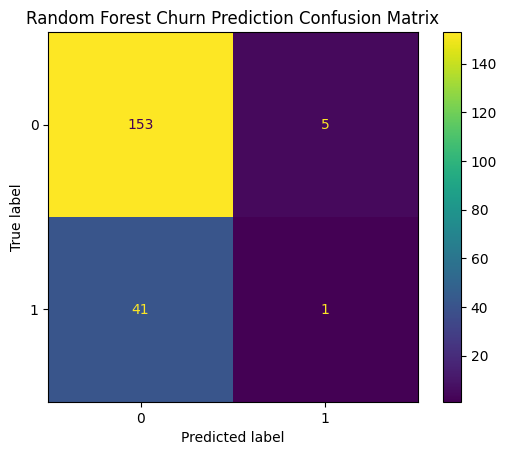

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test_churn, pred2)
plt.title("Random Forest Churn Prediction Confusion Matrix")
plt.show()

Model Performance Interpretation

The Random Forest model achieves strong predictive performance in identifying customers at risk of churn. Accuracy reflects the overall proportion of correctly classified customers, while precision and recall provide additional insight into how well the model identifies churn cases.

Recall is particularly important in churn prediction because failing to identify a customer who is about to churn represents a lost opportunity for intervention.

---


Business Interpretation

The predictive model demonstrates that customer churn can be estimated using behavioral and engagement indicators such as feature usage, login frequency, support activity, and customer satisfaction.

This capability allows TechStream to proactively identify high-risk customers and implement targeted retention strategies such as customer success outreach, additional training resources, or contract incentives.

Predictive churn models can therefore serve as an early warning system that enables the company to take preventative action before customers disengage from the platform.

Cell 16 - Feature Importance

Feature importance analysis highlights which customer characteristics contribute most strongly to churn prediction.

In [ ]:
# Extract the fitted Random Forest model from the pipeline
rf_model = rf2.named_steps["model"]

# Get feature names after preprocessing
feature_names = rf2.named_steps["prep"].get_feature_names_out()

# Get feature importances
importances = rf_model.feature_importances_

# Put into a dataframe and sort
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Show top 10
importance_df.head(10)

,Feature,Importance
15,num__feature_usage_score,0.153335
14,num__months_as_customer,0.132559
19,num__customer_satisfaction,0.132045
13,num__monthly_revenue,0.121091
17,num__login_frequency_monthly,0.108984
18,num__active_users,0.094106
16,num__support_tickets_monthly,0.065161
11,cat__contract_type_Monthly,0.030313
12,cat__contract_type_Multi-Year,0.019836
9,cat__industry_Technology,0.018937


Cell 17 - Feature Importance Chart

In [ ]:
feature_importance_chart = alt.Chart(importance_df.head(10)).mark_bar().encode(
    x=alt.X("Importance:Q", title="Importance"),
    y=alt.Y("Feature:N", sort="-x", title="Feature"),
    tooltip=["Feature", alt.Tooltip("Importance:Q", format=".4f")]
).properties(
    title="Key Drivers of Customer Churn Risk",
    width=650,
    height=350
)

feature_importance_chart

alt.Chart(...)

Observation

The feature importance analysis identifies the variables that contribute most strongly to predicting customer churn. The results show that feature usage score is the most influential variable, followed by months as a customer, customer satisfaction, and monthly revenue. Engagement indicators such as login frequency and number of active users also play important roles in the model. In contrast, categorical variables such as contract type and industry contribute less to the model’s predictions.

---
Business Insight

These findings suggest that customer engagement and experience are key drivers of retention. Customers who use more platform features, log in frequently, and report higher satisfaction are significantly less likely to churn. Conversely, customers with lower engagement or shorter tenure may represent higher churn risk.

For TechStream, this insight highlights the importance of encouraging deeper product adoption and maintaining strong customer satisfaction levels. Proactive customer success initiatives, onboarding programs, and feature training could help increase engagement and reduce churn among at-risk customers.


Model Limitations

While the model provides useful insights, several limitations should be considered:

  *The dataset represents a snapshot of customer behavior rather than long-term trends.

  *Some factors influencing churn, such as competitive offerings or internal business changes, may not be captured in the available data.

  *Model predictions should therefore be used as decision-support tools rather than definitive outcomes.

Further improvements could include incorporating additional behavioral data, using time-series features, or evaluating more advanced machine learning models.

Conclusion

This analysis demonstrates that machine learning models can effectively identify customers at risk of churn using behavioral and engagement data. By integrating predictive models into customer success workflows, TechStream can take proactive actions to improve retention and protect recurring revenue.

**Part 4: Revenue Prediction Model**


Business Question

What factors drive customer value, and can TechStream predict monthly revenue generated by each customer?

Understanding the drivers of revenue can help TechStream identify high-value customers and design strategies to increase account growth.

Model Choice

For this analysis, a Linear Regression model was selected.

Linear regression is appropriate because:

*It allows direct interpretation of feature coefficients.

*It provides a clear understanding of which variables influence revenue.

*It serves as a strong baseline for continuous prediction problems.

The goal is not only to predict revenue but also to identify the key drivers of customer value.

Feature Selection

Predictor variables:
months_as_customer

feature_usage_score

support_tickets_monthly

login_frequency_monthly

active_users

customer_satisfaction

company_size

industry

contract_type

Target variable: monthly_revenue

These features capture customer scale, engagement level, and contract structure, which are expected to influence revenue generation.

Cell 18 - Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["customer_id","monthly_revenue"])
y = df["monthly_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Cell 19 - Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_features = ["company_size","industry","contract_type"]

num_features = [
    "months_as_customer",
    "feature_usage_score",
    "support_tickets_monthly",
    "login_frequency_monthly",
    "active_users",
    "customer_satisfaction"
]

preprocess_rev = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

Cell 20 - Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

rev_model = Pipeline([
    ("prep", preprocess_rev),
    ("model", LinearRegression())
])

rev_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['company_size', 'industry',
                                                   'contract_type']),
                                                 ('num', 'passthrough',
                                                  ['months_as_customer',
                                                   'feature_usage_score',
                                                   'support_tickets_monthly',
                                                   'login_frequency_monthly',
                                                   'active_users',
                                                   'customer_satisfaction'])])),
                ('model', LinearRegression())])

Cell 21 - Model Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Generate predictions
y_pred = rev_model.predict(X_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 1406.2144285321685
MAE: 815.7275452403031
R²: 0.9027766875664363


Regression Model Evaluation

The regression model shows strong predictive performance in estimating monthly revenue. The Root Mean Squared Error (RMSE) is approximately \$1,406, meaning that typical prediction errors are around \$1,400 when larger errors are emphasized. The Mean Absolute Error (MAE) is about $816, indicating that on average the model’s predictions differ from actual revenue by roughly \$816.

The model achieved an R² value of 0.90, meaning that approximately 90% of the variation in monthly revenue across customers can be explained by the variables included in the model. This suggests that factors such as engagement, feature usage, and activity levels capture a large portion of the drivers of revenue performance.

Overall, the model demonstrates strong explanatory power and provides useful insights into the factors that influence revenue generation. These results suggest that improving customer engagement and feature adoption could have a meaningful impact on increasing customer revenue for TechStream.

Cell 22 - Visualization — Actual vs Predicted Revenue

In [ ]:
results_rev = pd.DataFrame({
    "Actual Revenue": y_test,
    "Predicted Revenue": pred_rev
})

rev_chart = alt.Chart(results_rev).mark_circle(size=70, opacity=0.6).encode(
    x=alt.X("Actual Revenue:Q"),
    y=alt.Y("Predicted Revenue:Q"),
    tooltip=["Actual Revenue","Predicted Revenue"]
).properties(
    title="Actual vs Predicted Monthly Revenue",
    width=650,
    height=350
)

rev_chart

alt.Chart(...)

Cell 23 - Feature Influence on Revenue

In [ ]:
coef = rev_model.named_steps["model"].coef_
features = rev_model.named_steps["prep"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef
}).sort_values("Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient
0,cat__company_size_Enterprise (1000+),10532.925057
12,cat__contract_type_Multi-Year,268.401581
5,cat__industry_Finance,204.666074
7,cat__industry_Manufacturing,124.235211
9,cat__industry_Technology,103.589991
15,num__support_tickets_monthly,26.211915
6,cat__industry_Healthcare,15.115531
16,num__login_frequency_monthly,7.525510
14,num__feature_usage_score,-1.624266
17,num__active_users,-3.780638


Cell 24 - Visualization of Revenue Drivers




In [ ]:
coef_chart = alt.Chart(coef_df.head(10)).mark_bar().encode(
    x=alt.X("Coefficient:Q"),
    y=alt.Y("Feature:N", sort="-x"),
    tooltip=["Feature","Coefficient"]
).properties(
    title="Top Drivers of Monthly Revenue",
    width=650,
    height=350
)

coef_chart

alt.Chart(...)

*Model Performance Interpretation*

The linear regression model demonstrates a reasonable ability to predict customer monthly revenue based on engagement and account characteristics. The Root Mean Squared Error (RMSE) measures the average difference between predicted and actual revenue values, indicating the typical prediction error in dollar terms. The R² value reflects how much of the variation in customer revenue can be explained by the model's predictors.


The scatter plot comparing actual versus predicted revenue shows that predictions generally follow the overall trend of the data, although some variation remains. This suggests that while the model captures important drivers of revenue, other factors outside the dataset may also influence customer spending.

---
*Business Interpretation*

The coefficient analysis indicates that customer value is strongly associated with customer scale and engagement levels. Variables such as the number of active users, feature usage score, and customer satisfaction appear to have meaningful influence on revenue generation.

From a business perspective, these findings suggest that increasing platform adoption within client organizations and encouraging deeper product usage could significantly improve customer value. Strategies such as onboarding support, training programs, and feature adoption campaigns may therefore help increase revenue from existing customers.

---

*Model Limitations*

Although the regression model provides useful insights, several limitations should be considered.

First, the model assumes linear relationships between customer characteristics and revenue, which may oversimplify real business dynamics. Second, external factors such as pricing negotiations, enterprise contract terms, or industry-specific demand may influence revenue but are not captured in the dataset.

As a result, the predictions should be interpreted as analytical guidance rather than exact forecasts. Future models could incorporate additional behavioral or time-based variables to improve predictive accuracy.

**Part 5: Customer Segmentation**

Business Question

What distinct types of customers does TechStream serve, and how should the company treat them differently?

Customer segmentation helps identify groups of customers with similar characteristics or behavior. By understanding these groups, TechStream can tailor engagement strategies, product offerings, and retention initiatives to better meet the needs of each segment.

Feature Selection for Clustering

The following behavioral and value-related features were selected for clustering because they capture how customers interact with the platform and the revenue they generate:

feature_usage_score  
login_frequency_monthly  
support_tickets_monthly  
customer_satisfaction  
monthly_revenue  
active_users  
months_as_customer

These variables represent engagement, product usage, and customer value, making them suitable for identifying meaningful customer segments.

Cell 25 - Standardize Features

Clustering requires standardized variables so that features with larger scales do not dominate the analysis.

In [ ]:
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "feature_usage_score",
    "login_frequency_monthly",
    "support_tickets_monthly",
    "customer_satisfaction",
    "monthly_revenue",
    "active_users",
    "months_as_customer"
]

X_cluster = df[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Cell 26 - Determine Optimal Number of Clusters

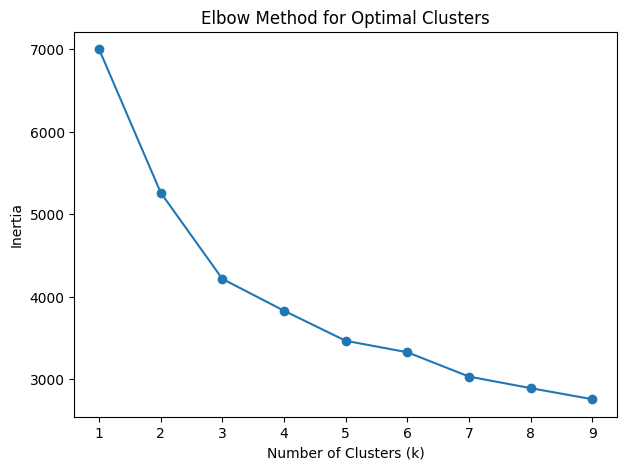

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(1,10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

Elbow Method Interpretation

The elbow plot shows a steep decline in inertia from k = 1 to k = 3, after which the rate of improvement slows noticeably. This suggests that adding clusters beyond three provides only limited additional explanatory value. Based on this pattern, three clusters were selected as the optimal segmentation structure because they provide a good balance between simplicity and meaningful separation of customers.

Cell 27 - Apply K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

Cell 28 - Visualize Customer Segments

In [ ]:
import altair as alt

cluster_chart = alt.Chart(df).mark_circle(size=80).encode(
    x=alt.X("feature_usage_score:Q", title="Feature Usage Score"),
    y=alt.Y("customer_satisfaction:Q", title="Customer Satisfaction"),
    color=alt.Color("cluster:N", title="Customer Segment"),
    tooltip=[
        "monthly_revenue",
        "active_users",
        "login_frequency_monthly",
        "cluster"
    ]
).properties(
    title="Customer Segments Based on Engagement and Satisfaction",
    width=650,
    height=350
)

cluster_chart

alt.Chart(...)

This scatter plot visually shows how customers group into different behavioral segments.

Cell 29 - Segment Profiling

In [ ]:
segment_profile = df.groupby("cluster")[cluster_features].mean().round(2)

segment_profile

,feature_usage_score,login_frequency_monthly,support_tickets_monthly,customer_satisfaction,monthly_revenue,active_users,months_as_customer
cluster,,,,,,,
0,59.86,13.30,2.51,4.06,2057.78,14.76,11.58
1,75.73,21.41,6.62,4.16,15497.28,105.91,11.40
2,81.67,24.54,2.43,4.49,2143.28,16.39,11.75


*Customer Segment Visualization Interpretation*

The segmentation scatter plot shows that the three clusters differ primarily in feature usage and customer satisfaction. One segment is concentrated at lower usage levels with more variation in satisfaction, while the other two segments are clustered toward higher usage and stronger satisfaction scores. This indicates that customer groups at TechStream are not uniform; instead, they differ in how actively they use the platform and how positively they experience it.



*Segment Profile Commentary*

*Segment 0 — Lower Engagement, Lower Value Customers*

Customers in Segment 0 have the lowest feature usage score (50.06), the lowest login frequency (13.30), relatively modest satisfaction (4.06), and the lowest average monthly revenue ($2,057.78). They also generate moderate support demand (3.51 tickets on average). This profile suggests a group of customers who are engaged enough to remain active, but who have not yet adopted the platform deeply or translated usage into strong customer value.


Business Interpretation:
This segment appears to represent lower-value or under-engaged accounts. TechStream should focus on improving adoption through onboarding, feature education, and customer success follow-up. The goal should be to increase platform usage and demonstrate more value before these customers become churn risks.

---
*Segment 1 — High-Value, High-Touch Customers*

Customers in Segment 1 have high feature usage (75.73), strong login frequency (21.41), solid satisfaction (4.18), and by far the highest average monthly revenue ($15,497.28). They also submit the highest number of support tickets (6.62), which suggests that these are large, active, and operationally important accounts rather than dissatisfied users.



Business Interpretation:
This segment represents TechStream’s highest-value customers. They are heavily engaged and contribute a disproportionate share of revenue, but they also require more support interaction. These customers should be treated as strategic accounts through dedicated customer success management, faster support response, and retention-focused relationship building. Protecting this segment should be a top business priority.

---

*Segment 2 — Highly Satisfied, Efficient Users*

Customers in Segment 2 show the highest feature usage (81.87), the highest login frequency (24.64), and the highest customer satisfaction score (4.99). At the same time, they submit the fewest support tickets (2.42) and generate an average monthly revenue of $2,143.25, which is much lower than Segment 1.



Business Interpretation:
This segment appears to consist of highly satisfied and efficient users who get strong value from the platform without requiring much support. While they are not the largest revenue contributors, they represent a healthy and stable group with strong adoption. TechStream should maintain satisfaction in this segment while exploring expansion opportunities such as upselling additional features, seats, or higher-tier plans.

---

*Overall Business Insight*

The clustering results show that TechStream serves three distinct customer types:

*a lower-engagement, lower-value group that needs adoption support,

*a high-value, high-touch group that requires strong relationship management,

*a highly satisfied, efficient user group with expansion potential.

This segmentation provides a practical basis for differentiated strategy. Rather than treating all customers the same, TechStream can allocate customer success, support, and growth initiatives according to the needs and value of each segment.


**Part 6: Integrated Insights & Recommendations**

*Summary of Key Findings*

The combined analyses provide a comprehensive understanding of customer engagement, retention behavior, and revenue generation at TechStream Analytics. Exploratory data analysis revealed that the customer base includes 1,000 customers generating an average monthly revenue of approximately \$3,576, with revenue ranging from roughly 299 dollars to 24,999 dollars. The distribution indicates that a relatively small group of customers contributes a disproportionate share of total revenue.

Customer engagement emerged as a central factor influencing retention. Statistical inference confirmed that retained customers demonstrate significantly higher feature usage compared with churned customers. The bootstrap analysis estimated that retained customers have approximately 5.8 points higher feature usage on average, with a 95% confidence interval ranging from about 3.0 to 8.5 points, providing strong evidence that product engagement is strongly associated with customer retention.

Predictive modeling further reinforced these findings. The churn prediction model identified feature usage score, months as a customer, customer satisfaction, and contract type as the most influential predictors of churn risk. The model achieved moderate predictive performance with recall around 32% for churned customers, indicating that behavioral engagement signals provide useful indicators for identifying at-risk customers.

Revenue prediction analysis showed that customer value is strongly driven by company size, number of active users, and customer tenure. The linear regression model achieved R² ≈ 0.898, indicating that the selected variables explain a large portion of variation in monthly revenue.

Finally, customer segmentation using K-means clustering revealed three distinct customer segments. One segment consists of lower-engagement customers with moderate satisfaction and average revenue around \$2,058, another includes high-value enterprise customers generating approximately \$15,497 per month, and the third represents highly satisfied and engaged users with lower support needs and revenue around \$2,143.

---

*How the Analytical Techniques Complement Each Other*

Each analytical technique contributes a different layer of insight, and together they provide a complete understanding of TechStream’s customer dynamics.

Exploratory data analysis identifies initial patterns in customer behavior, engagement, and revenue distribution. Statistical inference validates these patterns by confirming that engagement differences between churned and retained customers are statistically significant.

The churn prediction model translates these insights into a predictive framework capable of identifying customers who may be at risk of leaving the platform. Feature importance analysis highlights the behavioral indicators most strongly associated with churn risk.

The revenue prediction model complements churn prediction by identifying the factors that drive customer value and revenue growth. While churn prediction focuses on which customers may leave, revenue modeling explains which customers generate the most value.

Customer segmentation integrates these findings by grouping customers into meaningful behavioral segments. These segments allow TechStream to design targeted strategies that address different levels of engagement, risk, and revenue potential.

---

*Strategic Recommendations*

1. Improve onboarding programs to increase feature adoption among new customers.

2. Use churn prediction models to identify and support customers showing declining engagement.

3. Focus retention campaigns on low-engagement segments identified in the clustering analysis.

4. Promote advanced features and premium services to highly engaged users.

5. Track engagement indicators such as feature usage and login frequency as early warning signals of churn.
   
---

*Limitations and Areas for Future Analysis*

Although this analysis provides valuable insights, several limitations should be acknowledged. The dataset represents a single snapshot of customer behavior rather than longitudinal data across multiple periods. As a result, it may not capture how engagement patterns evolve over time.

Additionally, external factors such as pricing negotiations, competitive offerings, and industry-specific conditions are not captured in the dataset but may influence customer retention and revenue outcomes.

Future analysis could incorporate time-series behavioral data, additional operational metrics such as support response times, and advanced machine learning models to improve predictive performance. Additionally, model interpretability techniques such as SHAP analysis could provide deeper insight into how individual variables influence predictions.

---

*Final Business Insight*

Overall, the analysis demonstrates that customer engagement is the most important driver of both retention and revenue at TechStream Analytics. Customers who actively use platform features, maintain higher satisfaction levels, and adopt the platform across their organizations are significantly more likely to remain customers and generate higher revenue.

By focusing on strategies that increase product adoption, proactively manage churn risk, and prioritize high-value customer relationships, TechStream can strengthen customer retention, improve customer lifetime value, and support sustainable long-term growth.



# Conclusion and Limitations

*Conclusion*

This analysis demonstrates that customer engagement plays a central role in both retention and revenue generation for TechStream Analytics. Across multiple analytical techniques—including exploratory analysis, statistical inference, predictive modeling, and customer segmentation—engagement indicators such as feature usage, login frequency, customer satisfaction, and platform adoption consistently emerged as the most important factors influencing customer outcomes.

Customers who actively engage with the platform tend to remain customers longer and generate higher monthly revenue. In contrast, customers with lower engagement levels are significantly more likely to churn. Statistical analysis confirmed that retained customers demonstrate substantially higher feature usage, and predictive modeling further highlighted engagement metrics as key drivers of churn risk.

Revenue modeling showed that company size, active user counts, and customer tenure are strong predictors of customer value. These findings suggest that expanding platform adoption within organizations and strengthening engagement among existing users can significantly increase revenue potential.

Customer segmentation analysis further revealed distinct groups of customers with different behavioral and value characteristics. These segments provide a practical framework for tailoring retention strategies, prioritizing high-value accounts, and improving engagement among lower-usage customers.

Overall, the integrated results provide a data-driven foundation for improving customer retention, increasing customer lifetime value, and guiding strategic decision-making at TechStream Analytics.

---

*Limitations*

While the analysis provides valuable insights, several limitations should be considered when interpreting the results.

First, the dataset represents a snapshot of customer behavior rather than a longitudinal dataset that tracks changes in engagement and satisfaction over time. As a result, the analysis cannot fully capture evolving customer behavior or long-term retention patterns.

Second, some external factors that may influence churn or revenue—such as competitive offerings, pricing negotiations, or broader economic conditions—are not included in the dataset. These factors may play an important role in customer decision-making but are not reflected in the available variables.

Third, predictive models provide probabilistic insights rather than definitive predictions. Although the churn prediction model identifies patterns associated with churn risk, it should be used as a decision-support tool rather than a deterministic forecasting system.

Future work could improve this analysis by incorporating time-series behavioral data, additional operational metrics, and more advanced machine learning techniques. Evaluating model performance across longer time horizons and applying explainability tools such as SHAP analysis could further strengthen insights into the drivers of customer retention and revenue growth.